# 4_prediction_benchmark: prediction figures

Fig. 1d and Supplementary Fig. S2: five-fold cross-validated prediction of held-out perturbation effects, mean ± 1 SD over the folds for six methods.

- **Fig. 1d** (VCC-H1, Replogle-GW-K562): `{screen}_summary_metrics.csv` (`PAPER_PREDICTION_RESULTS`), written by `4_prediction_benchmark/evaluation/evaluate.py`.
- **Fig. S2** (the other ten datasets): the same files.

`USE_REFERENCE = True` (default) reads the metrics of the paper runs in `PAPER_PREDICTION_RESULTS`. With `USE_REFERENCE = False` (or `USE_REFERENCE=0`) it reads `<target>/summary_metrics.csv` under `PREDICTION_EVALUATION`, written by `bash 4_prediction_benchmark/run.sh`.

Each figure is written to `figures/` (PDF); the values plotted in both go to one table in `data/` (CSV).

In [1]:
%matplotlib inline
import os
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter, MaxNLocator
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # the repository root, for utils
from utils.paths import (
    DATASET_ORDER,
    PAPER_PREDICTION_RESULTS,
    PREDICTION_EVALUATION,
    REPO_ROOT,
    effect_key,
    paper_name,
)
from utils.plotting import MM, method_palette, save_panel, use_style

USE_REFERENCE = os.environ.get("USE_REFERENCE", "1") != "0"


def metrics_file(screen):
    if USE_REFERENCE:
        return PAPER_PREDICTION_RESULTS / f"{screen}_summary_metrics.csv"
    return PREDICTION_EVALUATION / screen / "summary_metrics.csv"


FIGURES = REPO_ROOT / "4_prediction_benchmark" / "figures"
DATA = REPO_ROOT / "4_prediction_benchmark" / "data"
FIGURES.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

## Per-fold metrics

Within each fold: weighted-MSE reduction 1 − wMSE / wMSE(train mean), PDS − 0.5, and the three residual cosines unchanged. The train mean is the dashed zero line of every panel and is not drawn.

In [2]:
# The 12 screens, by paper name; the prediction results are named by effect-dict key.
folds = []
for dataset in DATASET_ORDER:
    raw = pd.read_csv(metrics_file(effect_key(dataset)))
    train_mean = raw.loc[raw["method"].eq("train_mean")].set_index("seed")["mean_weighted_mse"]
    wide = pd.DataFrame({
        "dataset": paper_name(dataset),
        "seed": raw["seed"],
        "method_key": raw["method"],
        "weighted_mse_reduction": 1.0 - raw["mean_weighted_mse"] / raw["seed"].map(train_mean),
        "pds_above_chance": raw["mean_pds"] - 0.5,
        "residual_cosine": raw["mean_resid_cosine"],
        "residual_top20_cosine": raw["mean_resid_top20_pval_cosine"],
        "residual_top100_cosine": raw["mean_resid_top100_pval_cosine"],
    })
    folds.append(wide.melt(["dataset", "seed", "method_key"], var_name="metric", value_name="value"))
by_fold = pd.concat(folds, ignore_index=True)

## Fig. 1d

VCC-H1 and Replogle-GW-K562, five metrics, six methods; 110 × 105 mm. Y limits per panel: mean ± SD over the methods, extended to 0, span at least 0.04, padded by 10%. The metrics, methods, colors and limits are shared with Fig. S2.

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


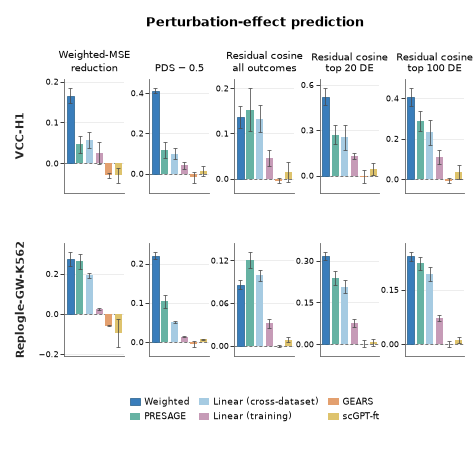

In [3]:
PRED_DATASETS = ["VCC-H1", "Replogle-GW-K562"]
PRED_METRICS = [
    ("weighted_mse_reduction", "Weighted-MSE\nreduction"),
    ("pds_above_chance", "PDS − 0.5"),
    ("residual_cosine", "Residual cosine\nall outcomes"),
    ("residual_top20_cosine", "Residual cosine\ntop 20 DE"),
    ("residual_top100_cosine", "Residual cosine\ntop 100 DE"),
]
# (method key, label, fill, edge); the Fig 2b colors, with Weighted, the focal method, darker and outlined
PRED_METHODS = [("weighted", "Weighted", "#397DBB", "#2C648F")] + [(*method, "none") for method in method_palette(
    ["presage", "linear_embedding_from_otherds_10", "paper_linear_embedding_from_training_10", "gears", "scGPT-ft"]
)]


def summarize(datasets):
    # mean, SD (ddof = 1) and fold count of each plotted method
    plotted = by_fold.loc[
        by_fold["dataset"].isin(datasets)
        & by_fold["method_key"].isin([key for key, *_ in PRED_METHODS])
    ]
    return plotted.groupby(["dataset", "metric", "method_key"], as_index=False).agg(
        mean=("value", "mean"), sd=("value", "std"), n_folds=("seed", "nunique")
    )


def panel_limits(summary, dataset, metric):
    subset = summary.loc[summary["dataset"].eq(dataset) & summary["metric"].eq(metric)]
    lower = min(0.0, float((subset["mean"] - subset["sd"]).min()))
    upper = max(0.0, float((subset["mean"] + subset["sd"]).max()))
    span = max(upper - lower, 0.04)
    return lower - 0.10 * span, upper + 0.10 * span


def draw_fig1d(summary):
    use_style({
        "font.size": 6.1, "axes.linewidth": 0.55, "axes.edgecolor": "#5A5A5A", "xtick.major.size": 2.3,
        "ytick.major.size": 2.3, "xtick.major.width": 0.5, "ytick.major.width": 0.5,
        "ps.fonttype": 3,  # kept at the default: it also decides how the PDF embeds the minus sign
    }, open_axes=True)
    figure, axes = plt.subplots(
        nrows=len(PRED_DATASETS), ncols=len(PRED_METRICS), figsize=(110.0 * MM, 105.0 * MM), squeeze=False
    )
    figure.subplots_adjust(left=0.135, right=0.975, bottom=0.215, top=0.825, wspace=0.42, hspace=0.44)
    positions = np.arange(len(PRED_METHODS), dtype=float)

    for column, (metric, metric_title) in enumerate(PRED_METRICS):
        for row, dataset in enumerate(PRED_DATASETS):
            axis = axes[row, column]
            axis.set_axisbelow(True)
            axis.grid(axis="y", color="#E7E7E7", linewidth=0.48)
            axis.axhline(0.0, color="#777777", linewidth=0.65, linestyle=(0, (3, 2)), zorder=2)
            subset = summary.loc[
                summary["dataset"].eq(dataset) & summary["metric"].eq(metric)
            ].set_index("method_key")
            for x, (key, _label, fill, edge) in zip(positions, PRED_METHODS):
                record = subset.loc[key]
                axis.bar(
                    x, record["mean"], width=0.74, color=fill, edgecolor=edge,
                    linewidth=0.50 if key == "weighted" else 0.0, zorder=3,
                )
                axis.errorbar(
                    x, record["mean"], yerr=record["sd"], fmt="none", ecolor="#4A4A4A",
                    elinewidth=0.50, capsize=1.20, capthick=0.50, zorder=4,
                )
            axis.set_xlim(-0.62, len(PRED_METHODS) - 0.38)
            axis.set_ylim(*panel_limits(summary, dataset, metric))
            axis.set_xticks([])
            axis.yaxis.set_major_locator(MaxNLocator(nbins=3, prune=None))
            axis.tick_params(axis="y", labelsize=5.4, pad=1.4)
            axis.spines[["bottom", "left"]].set_color("#666666")
            if row == 0:
                axis.set_title(metric_title, fontsize=6.5, pad=5.0, linespacing=1.24)

    for row, dataset in enumerate(PRED_DATASETS):
        axes[row, 0].text(
            -0.73, 0.5, dataset, transform=axes[row, 0].transAxes, rotation=90, rotation_mode="anchor",
            ha="center", va="center", fontsize=7.0, fontweight="semibold", color="#252525", clip_on=False,
        )
    figure.suptitle("Perturbation-effect prediction", x=0.535, y=0.963, fontsize=8.8, fontweight="semibold")
    handles = [
        Patch(facecolor=fill, edgecolor=edge, linewidth=0.50 if key == "weighted" else 0.0, label=label)
        for key, label, fill, edge in PRED_METHODS
    ]
    figure.legend(
        handles=handles, loc="lower center", bbox_to_anchor=(0.535, 0.064), ncol=3, fontsize=5.8,
        handlelength=1.15, handleheight=0.8, handletextpad=0.45, columnspacing=1.05, borderaxespad=0.0,
    )
    return figure


fig1d = draw_fig1d(summarize(PRED_DATASETS))
save_panel(fig1d, FIGURES / "prediction_benchmark_VCC-H1_Replogle-GW-K562.pdf")

## Fig. S2

The Fig. 1d benchmark for the other ten datasets, in manuscript order in two blocks of five; bar width 0.55; 183 × 150 mm.

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


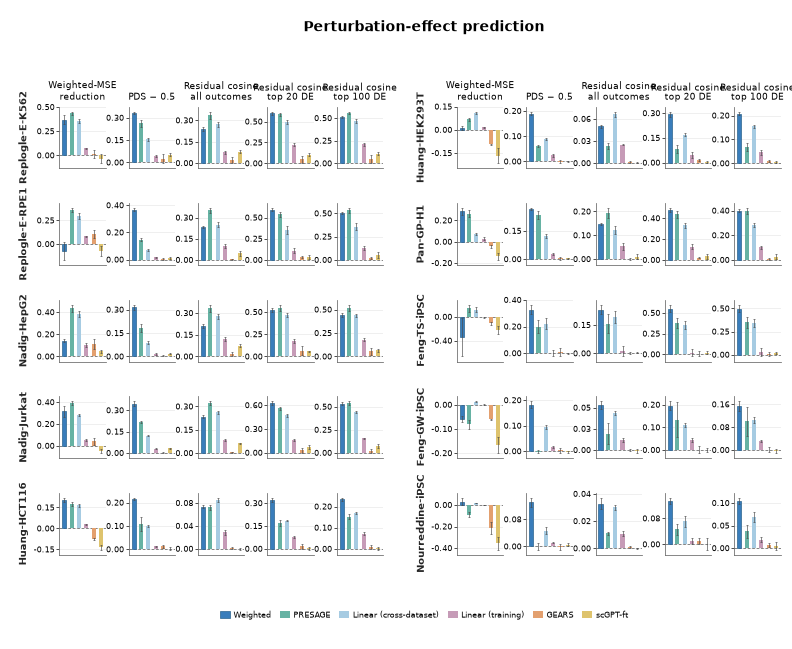

In [4]:
FIGS2_DATASET_BLOCKS = [
    ["Replogle-E-K562", "Replogle-E-RPE1", "Nadig-HepG2", "Nadig-Jurkat", "Huang-HCT116"],
    ["Huang-HEK293T", "Pan-GP-H1", "Feng-TS-iPSC", "Feng-GW-iPSC", "Nourreddine-iPSC"],
]


def draw_figs2(summary):
    use_style({
        "font.size": 5.8, "axes.linewidth": 0.50, "axes.edgecolor": "#5A5A5A", "xtick.major.size": 2.0,
        "ytick.major.size": 2.0, "xtick.major.width": 0.45, "ytick.major.width": 0.45, "ps.fonttype": 3,
    }, open_axes=True)
    figure = plt.figure(figsize=(183.0 * MM, 150.0 * MM))
    grid = figure.add_gridspec(
        nrows=5, ncols=11, width_ratios=[1, 1, 1, 1, 1, 0.60, 1, 1, 1, 1, 1],
        left=0.075, right=0.985, bottom=0.145, top=0.835, wspace=0.52, hspace=0.56,
    )
    positions = np.arange(len(PRED_METHODS), dtype=float)

    for block, datasets in enumerate(FIGS2_DATASET_BLOCKS):
        for row, dataset in enumerate(datasets):
            row_axes = []
            for column, (metric, metric_title) in enumerate(PRED_METRICS):
                axis = figure.add_subplot(grid[row, 6 * block + column])
                row_axes.append(axis)
                axis.set_axisbelow(True)
                axis.grid(axis="y", color="#E7E7E7", linewidth=0.42)
                axis.axhline(0.0, color="#777777", linewidth=0.58, linestyle=(0, (3, 2)), zorder=2)
                subset = summary.loc[
                    summary["dataset"].eq(dataset) & summary["metric"].eq(metric)
                ].set_index("method_key")
                for x, (key, _label, fill, edge) in zip(positions, PRED_METHODS):
                    record = subset.loc[key]
                    axis.bar(
                        x, record["mean"], width=0.55, color=fill, edgecolor=edge,
                        linewidth=0.46 if key == "weighted" else 0.0, zorder=3,
                    )
                    axis.errorbar(
                        x, record["mean"], yerr=record["sd"], fmt="none", ecolor="#4A4A4A",
                        elinewidth=0.42, capsize=0.90, capthick=0.42, zorder=4,
                    )
                axis.set_xlim(-0.65, len(PRED_METHODS) - 0.35)
                axis.set_ylim(*panel_limits(summary, dataset, metric))
                axis.set_xticks([])
                axis.yaxis.set_major_locator(MaxNLocator(nbins=3, prune=None))
                axis.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
                axis.tick_params(axis="y", labelsize=5.0, pad=1.1)
                axis.spines[["bottom", "left"]].set_color("#666666")
                if row == 0:
                    axis.set_title(metric_title, fontsize=5.8, pad=4.5, linespacing=1.20)
            row_axes[0].text(
                -0.78, 0.5, dataset, transform=row_axes[0].transAxes, rotation=90, rotation_mode="anchor",
                ha="center", va="center", fontsize=6.3, fontweight="semibold", color="#252525", clip_on=False,
            )

    figure.suptitle("Perturbation-effect prediction", x=0.535, y=0.968, fontsize=9.0, fontweight="semibold")
    handles = [
        Patch(facecolor=fill, edgecolor=edge, linewidth=0.46 if key == "weighted" else 0.0, label=label)
        for key, label, fill, edge in PRED_METHODS
    ]
    figure.legend(
        handles=handles, loc="lower center", bbox_to_anchor=(0.535, 0.040), ncol=6, fontsize=5.5,
        handlelength=1.20, handleheight=0.82, handletextpad=0.42, columnspacing=1.05, borderaxespad=0.0,
    )
    return figure


figs2 = draw_figs2(summarize([dataset for block in FIGS2_DATASET_BLOCKS for dataset in block]))
save_panel(figs2, FIGURES / "prediction_benchmark_other_datasets.pdf")

## Plotted values

Mean, SD and number of folds of every bar in Fig. 1d and S2, in plotting order (panel, dataset, metric, method).

In [5]:
panels = {dataset: "Fig. 1d" for dataset in PRED_DATASETS}
panels |= {dataset: "Supplementary Fig. S2" for block in FIGS2_DATASET_BLOCKS for dataset in block}
order = pd.MultiIndex.from_product(
    [list(panels), [metric for metric, _ in PRED_METRICS], [key for key, *_ in PRED_METHODS]],
    names=["dataset", "metric", "method_key"],
)
plotted = summarize(list(panels)).set_index(["dataset", "metric", "method_key"]).loc[order].reset_index()
plotted.insert(0, "panel", plotted["dataset"].map(panels))
plotted.insert(3, "metric_label", plotted["metric"].map({m: " ".join(t.split()) for m, t in PRED_METRICS}))
plotted.insert(5, "method", plotted["method_key"].map({k: label for k, label, *_ in PRED_METHODS}))
plotted.to_csv(DATA / "prediction_benchmark_summary.csv", index=False)